In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import MultiPolygon, Polygon
from shapely import wkt
import matplotlib.pyplot as plt

In [2]:
nbhds = gpd.read_file("Analysis_Neighborhoods_SF.csv")

locations = gpd.read_file("Film_Locations_SF.csv")

In [3]:
loc_gpf = gpd.GeoDataFrame(
    locations, geometry=gpd.points_from_xy(locations.Longitude, locations.Latitude), crs=7132
)

In [4]:
nbhds['the_geom'] = nbhds['the_geom'].apply(wkt.loads)


In [5]:
nbhds_gpf = gpd.GeoDataFrame(
    nbhds, geometry="the_geom", crs=7132
)

<function matplotlib.pyplot.show(close=None, block=None)>

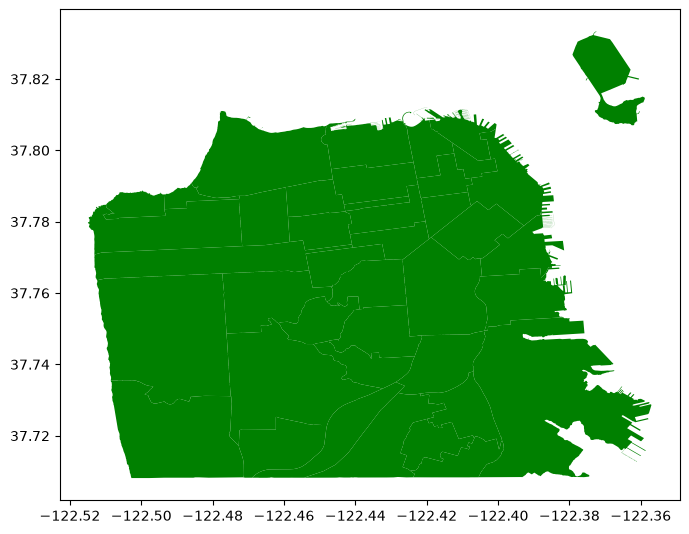

In [6]:
fig, ax = plt.subplots(figsize=(8,7))
nbhds_gpf.plot(ax=ax, color='green')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

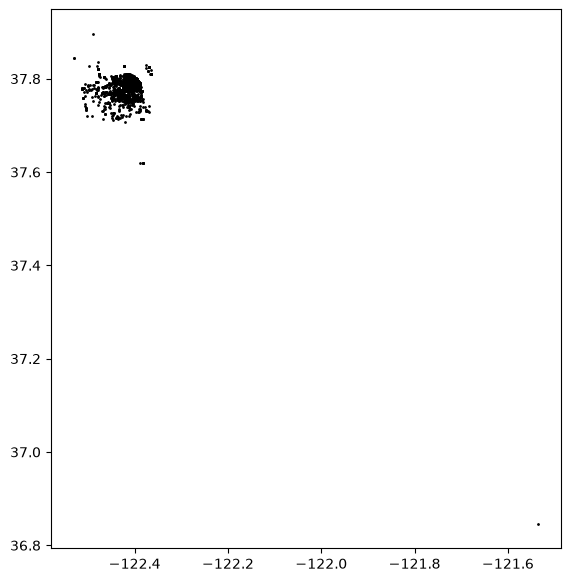

In [28]:
fig, ax = plt.subplots(figsize=(8,7))
loc_gpf.plot(ax=ax, markersize=1,color='black')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

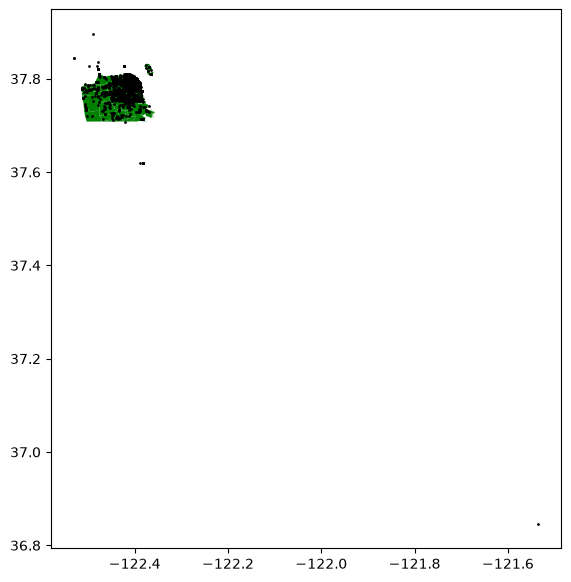

In [8]:
fig, ax = plt.subplots(figsize=(8,7))
nbhds_gpf.plot(ax=ax, color='green')
loc_gpf.plot(ax=ax, markersize=1,color='black')
plt.show

In [9]:
loc_nbhds_sj = loc_gpf.sjoin(nbhds_gpf, predicate="within")
loc_nbhds_sj

,Title,Release Year,Distributor,Production,Longitude,Latitude,geometry,index_right,nhood
0,Chance Season 2,2017,Hulu,TVM Productions Inc.,-122.4058222,37.8023949,POINT (-122.406 37.802),15,North Beach
1,Red Widow,2013,American Broadcasting Company (ABC),Beyond Pix,-122.4110311,37.7927806,POINT (-122.411 37.793),20,Nob Hill
3,Americana,2015,,Sutro Films LLC,-122.4484231,37.8029308,POINT (-122.448 37.803),24,Marina
4,DEVS,2020,FX Network,Minim Productions,-122.4176189,37.800359,POINT (-122.418 37.8),23,Russian Hill
5,"Murder in the First, Season 1",2014,Turner Network Television (TNT),Turner North Center Productions,-122.4087417,37.7939662,POINT (-122.409 37.794),37,Chinatown
...,...,...,...,...,...,...,...,...,...
2122,Nora Prentiss,1947,Warner Bros. Pictures,Warner Bros. Pictures,-122.4133224,37.7884549,POINT (-122.413 37.788),20,Nob Hill
2123,Ant-Man and the Wasp,2018,Walt Disney Studios Motion Pictures,"PYM Particles Productions II, LLC",-122.41491,37.79596,POINT (-122.415 37.796),20,Nob Hill
2124,Venom,2018,"Columbia Pictures, Sony Pictures Releasing","L.O.Z. Productions, Inc.",-122.4102464,37.8007752,POINT (-122.41 37.801),15,North Beach
2125,Looking Season 2 ep 206,2015,HBO,"Mission Street Productions, LLC",-122.43489,37.771831,POINT (-122.435 37.772),31,Haight Ashbury


In [18]:
counts = loc_nbhds_sj['nhood'].value_counts('index_right')

counts

nhood
Financial District/South Beach    0.144514
North Beach                       0.097632
Nob Hill                          0.079749
Chinatown                         0.078782
Mission                           0.073949
Tenderloin                        0.067666
Castro/Upper Market               0.042533
Russian Hill                      0.041566
South of Market                   0.038666
Potrero Hill                      0.034316
Hayes Valley                      0.032383
Marina                            0.028033
Haight Ashbury                    0.026583
Pacific Heights                   0.024650
Golden Gate Park                  0.018850
Mission Bay                       0.018850
Presidio                          0.017883
Bayview Hunters Point             0.016433
Treasure Island                   0.014983
Outer Richmond                    0.013050
West of Twin Peaks                0.009667
Bernal Heights                    0.009183
Sunset/Parkside                   0.008217
Twin 

In [22]:
counted = counts * 100

counted

nhood
Financial District/South Beach    14.451426
North Beach                        9.763171
Nob Hill                           7.974867
Chinatown                          7.878202
Mission                            7.394877
Tenderloin                         6.766554
Castro/Upper Market                4.253262
Russian Hill                       4.156597
South of Market                    3.866602
Potrero Hill                       3.431609
Hayes Valley                       3.238279
Marina                             2.803287
Haight Ashbury                     2.658289
Pacific Heights                    2.464959
Golden Gate Park                   1.884969
Mission Bay                        1.884969
Presidio                           1.788304
Bayview Hunters Point              1.643306
Treasure Island                    1.498308
Outer Richmond                     1.304978
West of Twin Peaks                 0.966651
Bernal Heights                     0.918318
Sunset/Parkside           

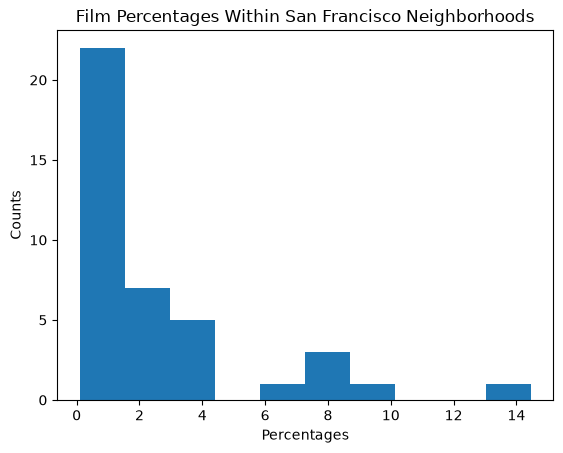

In [30]:
bx = counted.plot(kind='hist')

bx.set_title('Film Percentages Within San Francisco Neighborhoods')
bx.set_xlabel('Percentages')
bx.set_ylabel('Counts')
plt.show()

In [37]:
tbl_join = loc_nbhds_sj.merge(locations)

tbl_join

,Title,Release Year,Distributor,Production,Longitude,Latitude,geometry,index_right,nhood
0,Chance Season 2,2017,Hulu,TVM Productions Inc.,-122.4058222,37.8023949,POINT (-122.406 37.802),15,North Beach
1,Red Widow,2013,American Broadcasting Company (ABC),Beyond Pix,-122.4110311,37.7927806,POINT (-122.411 37.793),20,Nob Hill
2,Americana,2015,,Sutro Films LLC,-122.4484231,37.8029308,POINT (-122.448 37.803),24,Marina
3,DEVS,2020,FX Network,Minim Productions,-122.4176189,37.800359,POINT (-122.418 37.8),23,Russian Hill
4,"Murder in the First, Season 1",2014,Turner Network Television (TNT),Turner North Center Productions,-122.4087417,37.7939662,POINT (-122.409 37.794),37,Chinatown
...,...,...,...,...,...,...,...,...,...
2098,Nora Prentiss,1947,Warner Bros. Pictures,Warner Bros. Pictures,-122.4133224,37.7884549,POINT (-122.413 37.788),20,Nob Hill
2099,Ant-Man and the Wasp,2018,Walt Disney Studios Motion Pictures,"PYM Particles Productions II, LLC",-122.41491,37.79596,POINT (-122.415 37.796),20,Nob Hill
2100,Venom,2018,"Columbia Pictures, Sony Pictures Releasing","L.O.Z. Productions, Inc.",-122.4102464,37.8007752,POINT (-122.41 37.801),15,North Beach
2101,Looking Season 2 ep 206,2015,HBO,"Mission Street Productions, LLC",-122.43489,37.771831,POINT (-122.435 37.772),31,Haight Ashbury
